## 1. Import dependencies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gyanendramohanpatel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/gyanendramohanpatel/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 1. Importing the dataset
### 1.1 Load dataframe

In [3]:
# Load the 3 text files and concatenate them
import os
data_dir = "sentiment labelled sentences"
files = ["amazon_cells_labelled.txt", "imdb_labelled.txt", "yelp_labelled.txt"]

dfs = []
for file in files:
    filepath = os.path.join(data_dir, file)
    df = pd.read_csv(filepath, sep="\t", header=None, names=["sentence", "score"])
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df.head()


,sentence,score
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


### 1.2 Drop uneccessary columns

In [4]:
# In this dataset, we only have 'sentence' and 'score', so there are no columns to drop.
# We will just display the dataframe representation.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentence  2748 non-null   object
 1   score     2748 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 43.1+ KB


### 1.3 Check balance

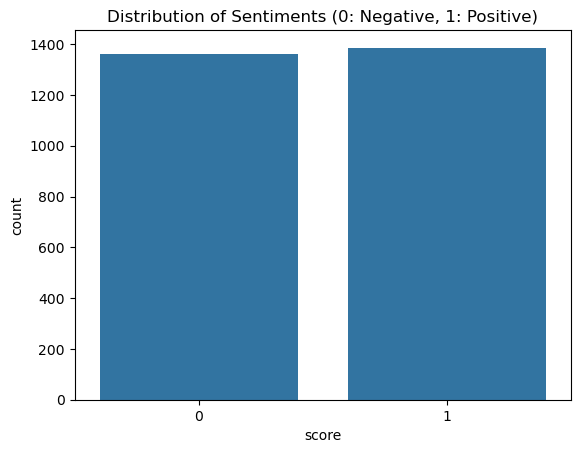

score
1    1386
0    1362
Name: count, dtype: int64


In [5]:
# 1 is positive, 0 is negative
sns.countplot(x='score', data=df)
plt.title("Distribution of Sentiments (0: Negative, 1: Positive)")
plt.show()

print(df['score'].value_counts())


### 1.4 Trim size of dataframe (optional)

In [6]:
# The dataset has 3000 rows (1500 positive, 1500 negative). It is small enough to train quickly, so we won't trim it.
# df = df.sample(frac=0.5, random_state=42) # Uncomment to trim
print("Dataset shape:", df.shape)


Dataset shape: (2748, 2)


## 2. Cleaning and pre-processing the data
### 2.1 Inspect data

In [7]:
# Checking for missing values
print(df.isnull().sum())
# Looking at a few full sentences
for i in range(5):
    print(f"[{df['score'].iloc[i]}] {df['sentence'].iloc[i]}")


sentence    0
score       0
dtype: int64
[0] So there is no way for me to plug it in here in the US unless I go by a converter.
[1] Good case, Excellent value.
[1] Great for the jawbone.
[0] Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!
[1] The mic is great.


### 2.3 Preprocessing all sentences (tweets/reviews)

In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove HTML tags (if any)
    text = re.sub('<.*?>', '', text)
    # Remove punctuation and non-alphabetic characters
    text = re.sub('[^a-zA-Z]', ' ', text)
    # Tokenize and remove stopwords, then lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['clean_sentence'] = df['sentence'].apply(preprocess_text)
df[['sentence', 'clean_sentence']].head()


,sentence,clean_sentence
0,So there is no way for me to plug it in here i...,way plug u unless go converter
1,"Good case, Excellent value.",good case excellent value
2,Great for the jawbone.,great jawbone
3,Tied to charger for conversations lasting more...,tied charger conversation lasting minute major...
4,The mic is great.,mic great


## 3. Analyze the data
### 3.1 Inspect some data

In [11]:
# Let's see some preprocessed vs original data
df.sample(5)[['sentence', 'clean_sentence', 'score']]


,sentence,clean_sentence,score
938,Logitech Bluetooth Headset is a 10!.,logitech bluetooth headset,1
690,The nokia CA-42 USB cable did not work with my...,nokia ca usb cable work phone,0
1986,If she had not rolled the eyes we may have sta...,rolled eye may stayed sure go back try,0
2337,The kids play area is NASTY!,kid play area nasty,0
2011,"Good service, very clean, and inexpensive, to ...",good service clean inexpensive boot,1


### 3.2 Analyze most common words

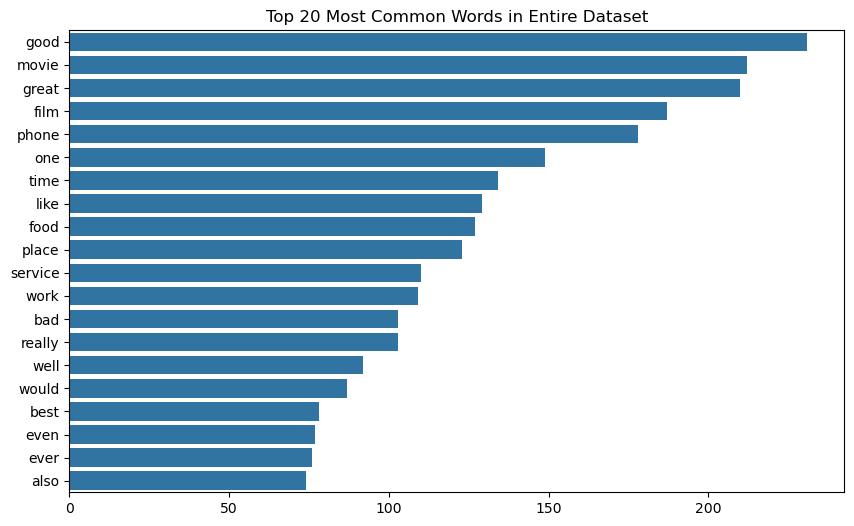

In [12]:
corpus = ' '.join(df['clean_sentence'].tolist())
word_freq = Counter(corpus.split())
common_words = word_freq.most_common(20)

words, counts = zip(*common_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Most Common Words in Entire Dataset")
plt.show()


### 3.3 Word cloud of most common positive words

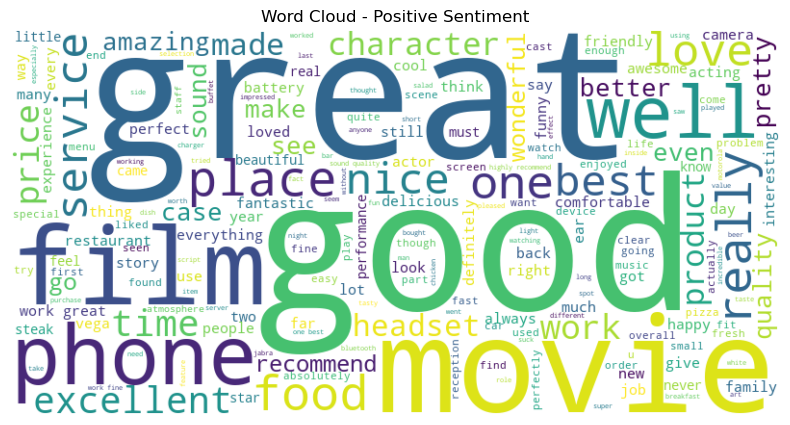

In [13]:
positive_corpus = ' '.join(df[df['score'] == 1]['clean_sentence'].tolist())
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_corpus)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Positive Sentiment")
plt.show()


### 3.4 Word cloud of most common negative words

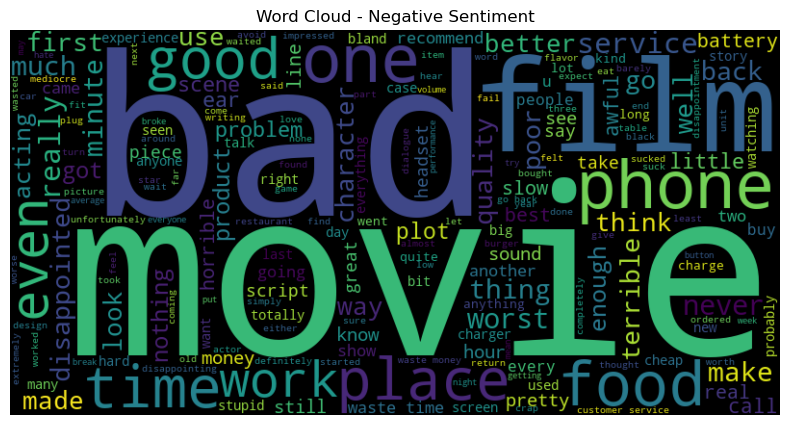

In [14]:
negative_corpus = ' '.join(df[df['score'] == 0]['clean_sentence'].tolist())
wordcloud_neg = WordCloud(width=800, height=400, background_color='black').generate(negative_corpus)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Negative Sentiment")
plt.show()


### 3.5 Comments

In [15]:
# Comments/Observations:
print("As observed in the word clouds, positive sentiments have words like 'great', 'good', 'love', 'best'.")
print("Negative sentiments are characterized by words like 'bad', 'terrible', 'worst', 'disappointed'.")


As observed in the word clouds, positive sentiments have words like 'great', 'good', 'love', 'best'.
Negative sentiments are characterized by words like 'bad', 'terrible', 'worst', 'disappointed'.


## 4. Split the data into train & test

In [16]:
X = df['clean_sentence']
y = df['score']

# Vectorizing the text data
vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (2198, 4539)
Testing data shape: (550, 4539)


### 4.2 Comments

In [17]:
print("We mapped the text sentences into numerical features using TF-IDF Vectorization.")
print("The dataset is split into an 80% training set and 20% testing set.")


We mapped the text sentences into numerical features using TF-IDF Vectorization.
The dataset is split into an 80% training set and 20% testing set.


## 7. Naive Bayes

Accuracy: 0.8018181818181818

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.74      0.80       291
           1       0.75      0.88      0.81       259

    accuracy                           0.80       550
   macro avg       0.81      0.81      0.80       550
weighted avg       0.81      0.80      0.80       550



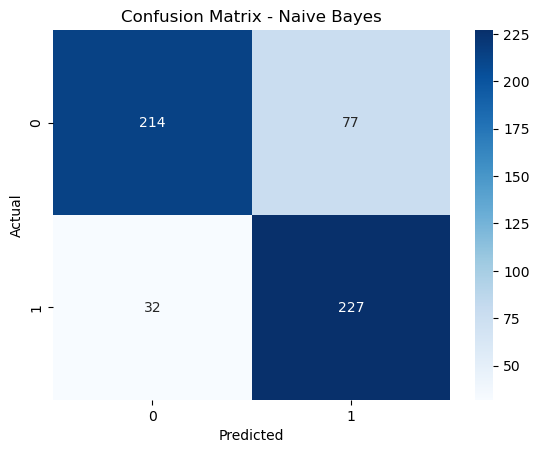

In [18]:
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()


In [ ]:
import pandas as pd

# Define the custom tweets
tweet1 = "Lunch at McDonalds today was not tasty"
tweet2 = "I am finally done with my homwork, feeling great" 
tweet3 = "Could have been better"

tweet4 = "The song was good!"
tweet5 = "The song was not good!"
tweet6 = "This song was great!"
tweet7 = "This song wasn't great!"

tweet8 = "That's just what I needed today.."
tweet9 = "I love being ignored" 
tweet10 = "Just broke my phone, awesome day thus far!"

tweet_list = [tweet1, tweet2, tweet3, tweet4, tweet5, tweet6, tweet7, tweet8, tweet9, tweet10]
custom_tweets = pd.DataFrame({'tweet': tweet_list})

custom_tweets['clean_tweet'] = custom_tweets['tweet'].apply(preprocess_text)

custom_vec = vectorizer.transform(custom_tweets['clean_tweet'])

custom_tweets['predicted_score'] = nb_classifier.predict(custom_vec)
custom_tweets['predicted_sentiment'] = custom_tweets['predicted_score'].map({1: 'Positive', 0: 'Negative'})
custom_tweets[['tweet', 'predicted_sentiment']]


,tweet,predicted_sentiment
0,Lunch at McDonalds today was not tasty,Positive
1,"I am finally done with my homwork, feeling great",Positive
2,Could have been better,Negative
3,The song was good!,Positive
4,The song was not good!,Positive
5,This song was great!,Positive
6,This song wasn't great!,Positive
7,That's just what I needed today..,Positive
8,I love being ignored,Positive
9,"Just broke my phone, awesome day thus far!",Positive
